In [ ]:
!git clone https://github.com/hyunwoongko/transformer.git
%cd transformer
!pip install torchtext==0.6.0 spacy --quiet
!python -m spacy download en_core_web_sm --quiet
!python -m spacy download de_core_news_sm --quiet

fatal: destination path 'transformer' already exists and is not an empty directory.
/content/transformer
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 41.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 86.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# The causal mask tensor

import torch

def make_causal_mask(seq_len):
    """Lower-triangular = causal. Upper triangle = -inf (masked out)."""
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask  # 1 = attend, 0 = masked

def make_pad_mask(seq, pad_idx=1):
    """Padding mask: 0 wherever token == pad_idx."""
    return (seq != pad_idx).unsqueeze(1).unsqueeze(2)

# Print what the masks actually look like
seq_len = 6
causal = make_causal_mask(seq_len)
print("Causal mask (decoder self-attention):")
print(causal.int())

Causal mask (decoder self-attention):
tensor([[1, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1]], dtype=torch.int32)


Text(0, 0.5, 'Decoder queries')

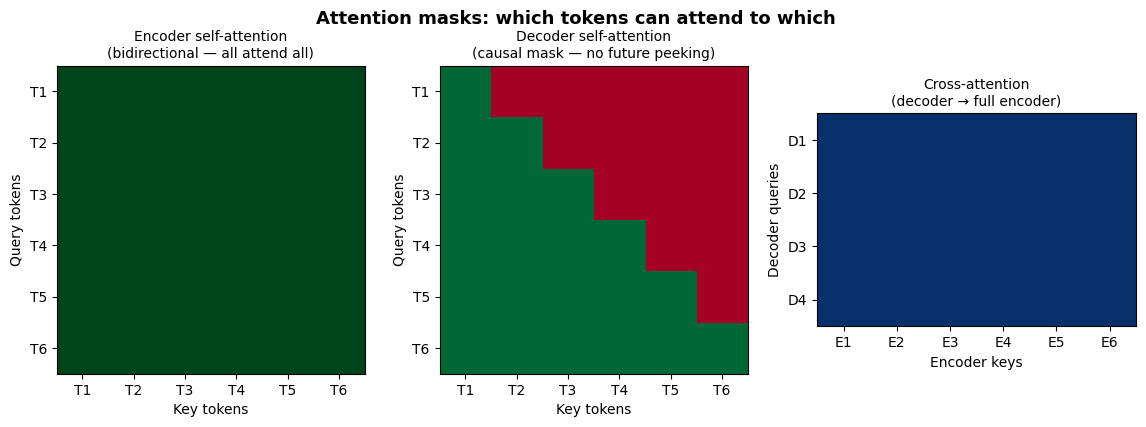

In [ ]:
# Three-panel mask visualization

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Attention masks: which tokens can attend to which",
             fontsize=13, fontweight='bold', y=1.02)

N = 6
labels = [f"T{i+1}" for i in range(N)]

# 1. Encoder self-attention — fully visible
enc_mask = np.ones((N, N))
im0 = axes[0].imshow(enc_mask, cmap='Greens', vmin=0, vmax=1)
axes[0].set_title("Encoder self-attention\n(bidirectional — all attend all)", fontsize=10)
axes[0].set_xticks(range(N)); axes[0].set_yticks(range(N))
axes[0].set_xticklabels(labels); axes[0].set_yticklabels(labels)
axes[0].set_xlabel("Key tokens"); axes[0].set_ylabel("Query tokens")

# 2. Decoder self-attention — causal lower triangle
dec_mask = np.tril(np.ones((N, N)))
im1 = axes[1].imshow(dec_mask, cmap='RdYlGn', vmin=0, vmax=1)
axes[1].set_title("Decoder self-attention\n(causal mask — no future peeking)", fontsize=10)
axes[1].set_xticks(range(N)); axes[1].set_yticks(range(N))
axes[1].set_xticklabels(labels); axes[1].set_yticklabels(labels)
axes[1].set_xlabel("Key tokens"); axes[1].set_ylabel("Query tokens")

# 3. Cross-attention — 4 decoder rows × 6 encoder cols (full)
D = 4
cross_mask = np.ones((D, N))
im2 = axes[2].imshow(cross_mask, cmap='Blues', vmin=0, vmax=1)
axes[2].set_title("Cross-attention\n(decoder → full encoder)", fontsize=10)
axes[2].set_xticks(range(N)); axes[2].set_yticks(range(D))
axes[2].set_xticklabels([f"E{i+1}" for i in range(N)])
axes[2].set_yticklabels([f"D{i+1}" for i in range(D)])
axes[2].set_xlabel("Encoder keys"); axes[2].set_ylabel("Decoder queries")



In [ ]:
# Show the actual −inf masking operation

print("\n=== What happens inside scaled_dot_product_attention ===\n")
scores = torch.tensor([[2.1, 0.8, -0.3, 1.5, 0.2, -1.1],
                        [0.5, 3.2,  1.1, 0.7, -0.4, 0.9],
                        [1.2, 0.6,  2.8, 0.3,  1.0, 0.2],
                        [0.9, 1.4,  0.7, 2.1, -0.2, 0.5],
                        [0.3, 0.8,  1.2, 0.6,  3.1, 0.4],
                        [0.7, 0.2,  0.9, 1.1,  0.5, 2.4]])

mask = make_causal_mask(6).bool()
masked_scores = scores.masked_fill(~mask, float('-inf'))
weights = torch.softmax(masked_scores, dim=-1)

print("Raw scores (QKᵀ / √d_k):")
print(scores.numpy().round(2))
print("\nAfter causal mask applied (upper triangle → −inf):")
print(masked_scores.numpy().round(2))
print("\nAfter softmax (−inf → 0.0, rows sum to 1.0):")
print(weights.numpy().round(3))


=== What happens inside scaled_dot_product_attention ===

Raw scores (QKᵀ / √d_k):
[[ 2.1  0.8 -0.3  1.5  0.2 -1.1]
 [ 0.5  3.2  1.1  0.7 -0.4  0.9]
 [ 1.2  0.6  2.8  0.3  1.   0.2]
 [ 0.9  1.4  0.7  2.1 -0.2  0.5]
 [ 0.3  0.8  1.2  0.6  3.1  0.4]
 [ 0.7  0.2  0.9  1.1  0.5  2.4]]

After causal mask applied (upper triangle → −inf):
[[ 2.1 -inf -inf -inf -inf -inf]
 [ 0.5  3.2 -inf -inf -inf -inf]
 [ 1.2  0.6  2.8 -inf -inf -inf]
 [ 0.9  1.4  0.7  2.1 -inf -inf]
 [ 0.3  0.8  1.2  0.6  3.1 -inf]
 [ 0.7  0.2  0.9  1.1  0.5  2.4]]

After softmax (−inf → 0.0, rows sum to 1.0):
[[1.    0.    0.    0.    0.    0.   ]
 [0.063 0.937 0.    0.    0.    0.   ]
 [0.154 0.084 0.762 0.    0.    0.   ]
 [0.147 0.243 0.121 0.489 0.    0.   ]
 [0.044 0.072 0.107 0.059 0.718 0.   ]
 [0.094 0.057 0.115 0.141 0.077 0.516]]


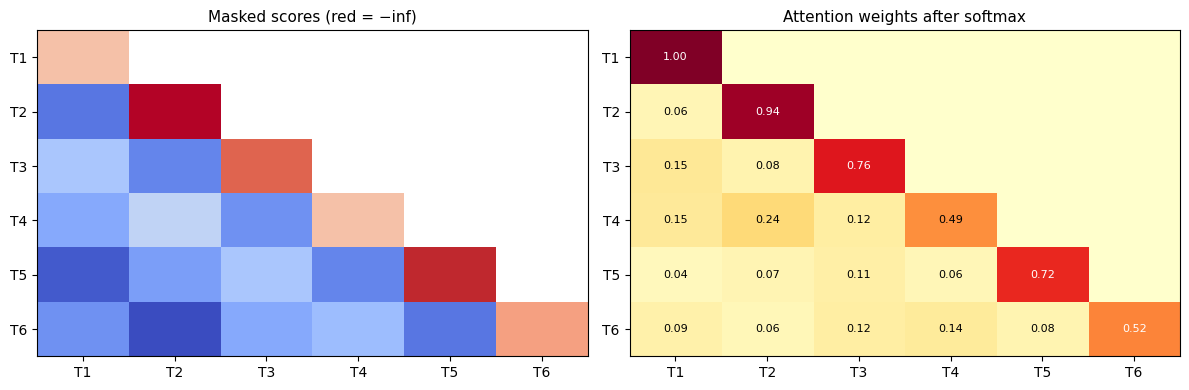

Saved: attention_weights.png


In [ ]:
#Visualize attention weights (heatmap)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(masked_scores.numpy(), cmap='coolwarm', aspect='auto')
axes[0].set_title("Masked scores (red = −inf)", fontsize=11)
axes[0].set_xticks(range(6)); axes[0].set_yticks(range(6))
axes[0].set_xticklabels(labels); axes[0].set_yticklabels(labels)

axes[1].imshow(weights.detach().numpy(), cmap='YlOrRd', aspect='auto')
axes[1].set_title("Attention weights after softmax", fontsize=11)
axes[1].set_xticks(range(6)); axes[1].set_yticks(range(6))
axes[1].set_xticklabels(labels); axes[1].set_yticklabels(labels)
for i in range(6):
    for j in range(6):
        val = weights[i,j].item()
        if val > 0.001:
            axes[1].text(j, i, f"{val:.2f}", ha='center', va='center',
                        fontsize=8, color='black' if val < 0.5 else 'white')

plt.tight_layout()
plt.savefig("attention_weights.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: attention_weights.png")